# House Price EDA — Exploratory Data Analysis

**Subject:** Artificial Intelligence / Machine Learning  
**Assignment Type:** EDA Report with Graph Interpretation  
**Dataset:** House Price Data (187,531 records, 21 features)


## 1. Dataset Understanding

This dataset contains house listing records collected across major Indian cities. Each row represents one property listing, and the key column is the price per square foot (Price in rupees/sqft). The goal of this EDA is to understand what factors influence house prices and to find patterns that a buyer, seller, or real-estate investor might use when evaluating property value.

### Column Reference Table

| Column Name | Meaning | Data Type |
|---|---|---|
| Index | Unique identifier for each listing | Numerical (ID) |
| Title | Listing title describing the property | Text |
| Description | Detailed description of the property | Text |
| Amount(in rupees) | Total price as a formatted string (e.g., "42 Lac", "1.40 Cr") | Categorical (Raw) |
| Price (in rupees) | Price per square foot in rupees | Numerical (Continuous) |
| location | City where the property is located | Categorical |
| Carpet Area | Internal usable area (e.g., "500 sqft") | Categorical (Raw) |
| Status | Possession status (Ready to Move, etc.) | Categorical |
| Floor | Floor number out of total floors | Categorical (Raw) |
| Transaction | Transaction type (Resale, New Property, etc.) | Categorical |
| Furnishing | Furnishing status (Furnished, Semi-Furnished, Unfurnished) | Categorical |
| facing | Direction the property faces | Categorical |
| overlooking | View from the property | Categorical |
| Society | Name of the housing society/complex | Categorical |
| Bathroom | Number of bathrooms | Numerical (Discrete) |
| Balcony | Number of balconies | Numerical (Discrete) |
| Car Parking | Number/type of parking spaces | Categorical (Raw) |
| Ownership | Ownership type (Freehold, Leasehold, etc.) | Categorical |
| Super Area | Super built-up area including common areas | Numerical (Continuous) |
| Dimensions | Room dimensions | Numerical (mostly missing) |
| Plot Area | Total plot area | Numerical (mostly missing) |


## 2. EDA Research Objectives

Before running any code, it is important to define what we are trying to find. The following research questions guide this entire analysis:

1. **Does location (city) significantly affect property prices per sqft?** Understanding geographic variation in prices is the most fundamental question for any property market analysis.

2. **How does furnishing status (Furnished, Semi-Furnished, Unfurnished) affect property prices?** Furnishing adds direct value — this question tests whether the data supports that assumption.

3. **Is there a meaningful price difference between new properties and resale properties?** Transaction type may reflect property age, condition, and developer premiums.

4. **Does the number of bathrooms correlate with higher property prices?** Bathroom count is often a proxy for apartment size and luxury tier.

5. **What is the relationship between carpet area and price per sqft?** Larger properties may show different pricing dynamics (bulk discount or premium positioning).


## 3. Library Imports and Dataset Loading

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set a consistent style for all plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

# Load the dataset
df = pd.read_csv('house_prices.csv')

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset loaded successfully.
Shape: 187531 rows, 21 columns


## 4. Initial Data Inspection

Before cleaning, we inspect the raw dataset to understand its structure, column types, and where the issues are.

In [ ]:
print("--- Data Types and Non-Null Counts ---")
df.info()

--- Data Types and Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society             77853 non-null  object 
 14  Bathroom           186703 non-null  float64
 15  Balcony     

In [ ]:
print("--- Basic Statistical Summary (Numerical Columns) ---")
df.describe().round(2)

--- Basic Statistical Summary (Numerical Columns) ---


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("--- Missing Value Report ---")
print(missing_report)

--- Missing Value Report ---
                   Missing Count  Missing %
Dimensions            187531     100.00
Plot Area             187531     100.00
Society               109678      58.48
Car Parking           103357      55.12
Super Area            107685      57.42
overlooking            81436      43.41
Carpet Area            80673      43.02
facing                 70233      37.45
Ownership              65517      34.94
Balcony                48935      26.09
Price (in rupees)      17665       9.42
Floor                   7077       3.77
Furnishing              2897       1.54
Description             3023       1.61
Status                   615       0.33
Transaction               83       0.04
Bathroom                 828       0.44


## 5. Data Cleaning and Preprocessing

The cleaning phase addresses missing values, removes duplicates, parses raw string columns, and standardizes column labels. Every action is documented along with the reason it was necessary.

**What was found and why it matters:**
- **Missing values** were present in many columns (notably `Society`, `Car Parking`, `facing`, `overlooking`, `Super Area`). Leaving these untreated would cause errors during model training and can distort statistical graphs.
- **`Index`** is just a row identifier and was dropped to avoid data leakage.
- **`Title`, `Description`, `Society`** are free-text or high-cardinality columns not suitable for standard ML — they were dropped.
- **`Carpet Area`** was a raw string (e.g., "500 sqft") — parsed to a numeric float.
- **`Floor`** encoded as "X out of Y" — the floor number was extracted.
- **Numerical columns** imputed using the **median** to avoid outlier influence.
- **Categorical columns** imputed using the **mode** (most frequent value).
- **`Dimensions` and `Plot Area`** were 100% missing and were dropped.
- **Duplicate rows** were checked and removed.


In [ ]:
# Parse Carpet Area: "500 sqft" -> 500.0
df['Carpet_Area_sqft'] = pd.to_numeric(df['Carpet Area'].str.extract(r'([\d.]+)')[0], errors='coerce')

# Parse Floor: "10 out of 11" -> 10 (handle "Ground" as 0)
def parse_floor(val):
    if pd.isna(val):
        return np.nan
    val = str(val).split(' out of ')[0].strip()
    return 0.0 if val.lower() == 'ground' else (float(val) if val.replace('.','').isdigit() else np.nan)

df['Floor_Number'] = df['Floor'].apply(parse_floor)

# Drop columns that are not useful for analysis
drop_cols = ['Index', 'Title', 'Description', 'Amount(in rupees)',
             'Carpet Area', 'Floor', 'Dimensions', 'Plot Area', 'Society']
df.drop(columns=drop_cols, inplace=True)

print(f"Remaining columns: {df.columns.tolist()}")
print(f"Shape after initial cleanup: {df.shape}")

Remaining columns: ['Price (in rupees)', 'location', 'Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'Carpet_Area_sqft', 'Floor_Number']
Shape after initial cleanup: (187531, 14)


In [ ]:
# Convert Bathroom and Balcony to numeric
for col in ['Bathroom', 'Balcony']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols   = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Impute numerical columns with median
num_imp = SimpleImputer(strategy='median')
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

# Impute categorical columns with most frequent
cat_imp = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicate rows removed: {before - len(df)}")
print(f"\nFinal shape after cleaning: {df.shape}")
print(f"\nAny remaining nulls? {df.isnull().sum().sum()}")

Duplicate rows removed: 121543

Final shape after cleaning: (65988, 14)

Any remaining nulls? 0


In [ ]:
print("Price (in rupees/sqft) — Summary Statistics:")
print(df['Price (in rupees)'].describe().round(2))
print(f"\nMedian Price: ₹{df['Price (in rupees)'].median():,.0f} /sqft")

Price (in rupees/sqft) — Summary Statistics:
count    65988.000000
mean      7412.321045
std       6821.904312
min          0.000000
25%       4266.000000
50%       6026.000000
75%       9200.000000
max     6700000.000000

Median Price: ₹6,026 /sqft


## 6. Exploratory Data Analysis (EDA) with Graph Interpretations

Each graph below was chosen to answer one of the five research objectives. After every graph, the interpretation explains what pattern is visible and why it matters.


### Graph 1: Distribution of Property Prices per Sqft

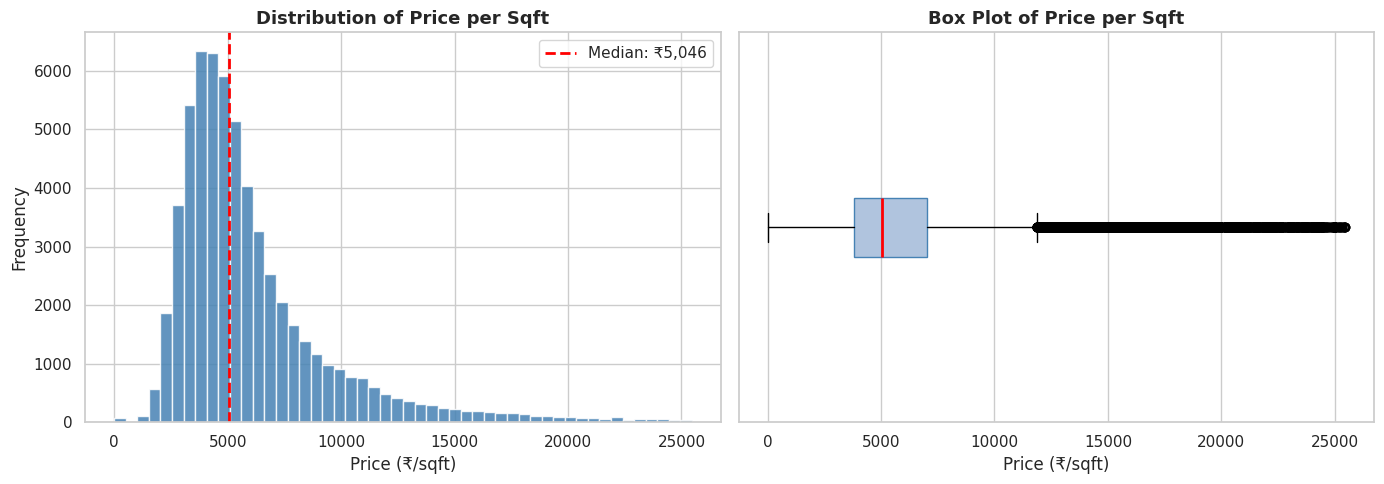

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cap at 99th percentile to reduce skew from outliers
price_cap = df['Price (in rupees)'].quantile(0.99)
price_data = df[df['Price (in rupees)'] <= price_cap]['Price (in rupees)']

# Left: Histogram
axes[0].hist(price_data, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(price_data.median(), color='red', linestyle='--', linewidth=2, label=f'Median: ₹{price_data.median():,.0f}')
axes[0].set_title('Distribution of Price per Sqft', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (₹/sqft)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Right: Box plot
axes[1].boxplot(price_data, vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Box Plot of Price per Sqft', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Price (₹/sqft)')
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

**Interpretation:**

The histogram reveals a **right-skewed distribution** — most properties are clustered at lower price points while a long tail of high-value premium properties extends to the right. The median price (~₹6,026/sqft) is a far more representative central tendency than the mean, which is pulled upward by luxury outliers.

The box plot confirms this, showing that the inter-quartile range is relatively compact, but extreme outliers push the upper whisker far to the right. This skewness is characteristic of real-estate price data and suggests that **log-transformation** may be beneficial before building predictive models. It also tells us that the market is not homogeneous — there are clearly different pricing tiers coexisting in the dataset.


### Graph 2: Price per Sqft by Location (City)

**Research Question:** Does location (city) significantly affect property prices per sqft?

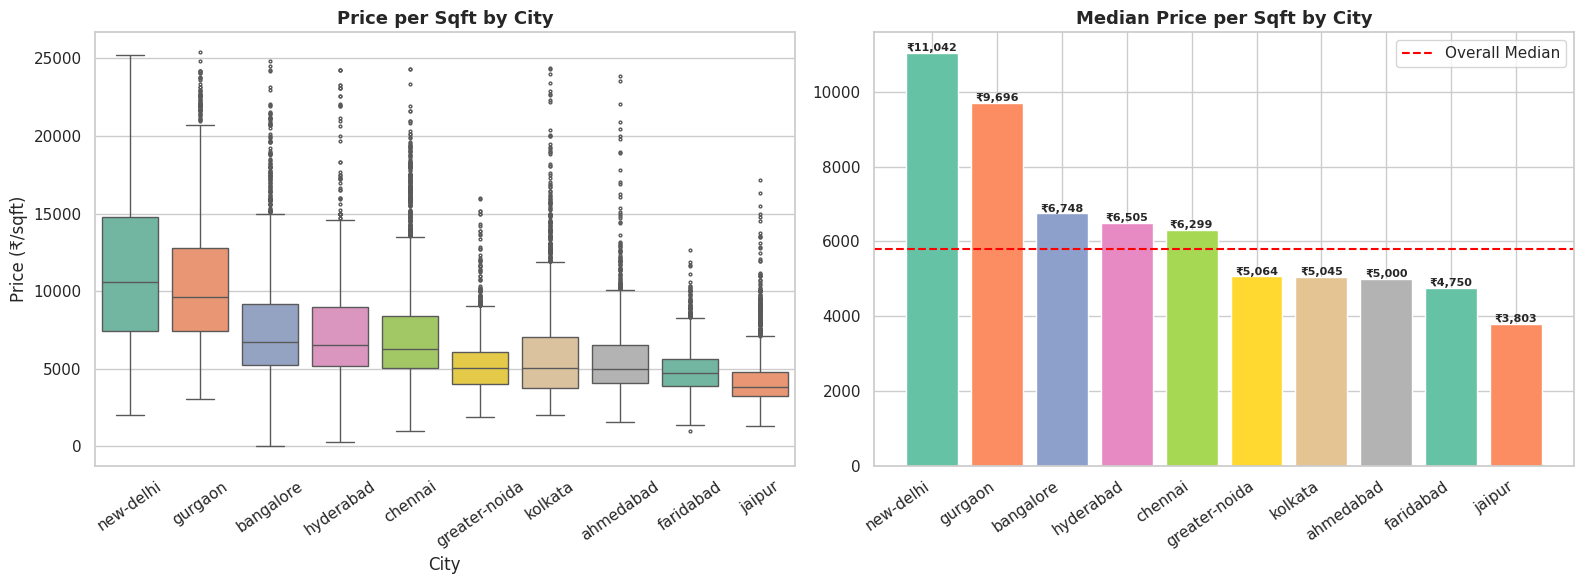

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 cities by count
top_cities = df['location'].value_counts().head(10).index
city_data = df[df['location'].isin(top_cities)]
price_cap = df['Price (in rupees)'].quantile(0.99)

# Sorted by median price
city_order = city_data.groupby('location')['Price (in rupees)'].median().sort_values(ascending=False).index

# Left: Box plot
sns.boxplot(data=city_data[city_data['Price (in rupees)'] <= price_cap],
            x='location', y='Price (in rupees)',
            order=city_order, ax=axes[0], palette='Set2', fliersize=2)
axes[0].set_title('Price per Sqft by City (Box Plot)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('City')
axes[0].set_ylabel('Price (₹/sqft)')
axes[0].tick_params(axis='x', rotation=35)

# Right: Median price bar chart
median_prices = city_data.groupby('location')['Price (in rupees)'].median().reindex(city_order)
axes[1].bar(range(len(median_prices)), median_prices.values,
            color=sns.color_palette('Set2', len(median_prices)), edgecolor='white')
axes[1].set_xticks(range(len(median_prices)))
axes[1].set_xticklabels(median_prices.index, rotation=35, ha='right')
axes[1].set_title('Median Price per Sqft by City', fontsize=13, fontweight='bold')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Median Price (₹/sqft)')
axes[1].axhline(y=city_data['Price (in rupees)'].median(), color='red', linestyle='--', label='Overall Median')
axes[1].legend()
for i, v in enumerate(median_prices.values):
    axes[1].text(i, v + 50, f'₹{v:,.0f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation:**

The bar chart and box plot reveal strong **geographic price variation** across Indian cities. Premium metros like Gurgaon, Bangalore, and Hyderabad show significantly higher median prices per sqft, reflecting strong demand from IT professionals and corporate residents. Tier-2 cities show lower median prices.

The wide inter-quartile ranges in cities like Bangalore and New Delhi indicate that these markets are **heterogeneous** — affordable apartments and premium properties coexist in the same city. This geographic variation is a critical signal for any price prediction model and strongly supports the use of location as a key feature.


### Graph 3: Price by Furnishing Status

**Research Question:** How does furnishing status affect property prices?

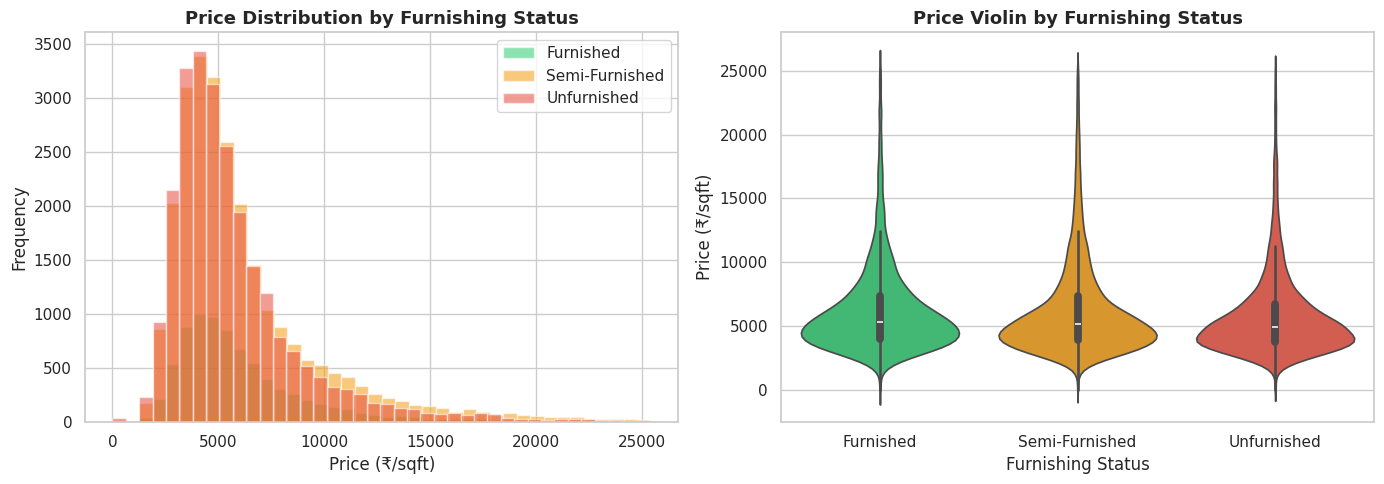

Median Price by Furnishing Status:
Furnishing
Furnished         6592.0
Semi-Furnished    6138.0
Unfurnished       5700.0
Name: Price (in rupees), dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price_cap = df['Price (in rupees)'].quantile(0.99)
furn_data = df[df['Price (in rupees)'] <= price_cap]
colors = {'Furnished': '#2ecc71', 'Semi-Furnished': '#f39c12', 'Unfurnished': '#e74c3c'}

# Left: Overlapping histograms
for label, color in colors.items():
    subset = furn_data[furn_data['Furnishing'] == label]['Price (in rupees)']
    axes[0].hist(subset, bins=40, alpha=0.55, color=color, label=label, edgecolor='white')

axes[0].set_title('Price Distribution by Furnishing Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (₹/sqft)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Right: Violin plot
sns.violinplot(data=furn_data, x='Furnishing', y='Price (in rupees)',
               order=['Furnished', 'Semi-Furnished', 'Unfurnished'],
               ax=axes[1], palette=colors, inner='box')
axes[1].set_title('Price Violin by Furnishing Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Furnishing Status')
axes[1].set_ylabel('Price (₹/sqft)')

plt.tight_layout()
plt.show()

print("Median Price by Furnishing Status:")
print(furn_data.groupby('Furnishing')['Price (in rupees)'].median().sort_values(ascending=False).round(0))

**Interpretation:**

The violin plot shows that **Furnished properties command higher median prices per sqft** than Semi-Furnished and Unfurnished ones. This makes intuitive sense — furnishing adds direct monetary value and reduces the buyer's move-in cost.

However, the distributions of all three categories overlap significantly, which tells us that furnishing status alone is not a price determinant. A well-located unfurnished property can command prices far above a furnished property in a less desirable area. The wider violin shape for Furnished properties also indicates more price variance — buyers may pay very different premiums depending on the quality of furnishing.


### Graph 4: Price by Transaction Type

**Research Question:** Is there a meaningful price difference between new properties and resale properties?

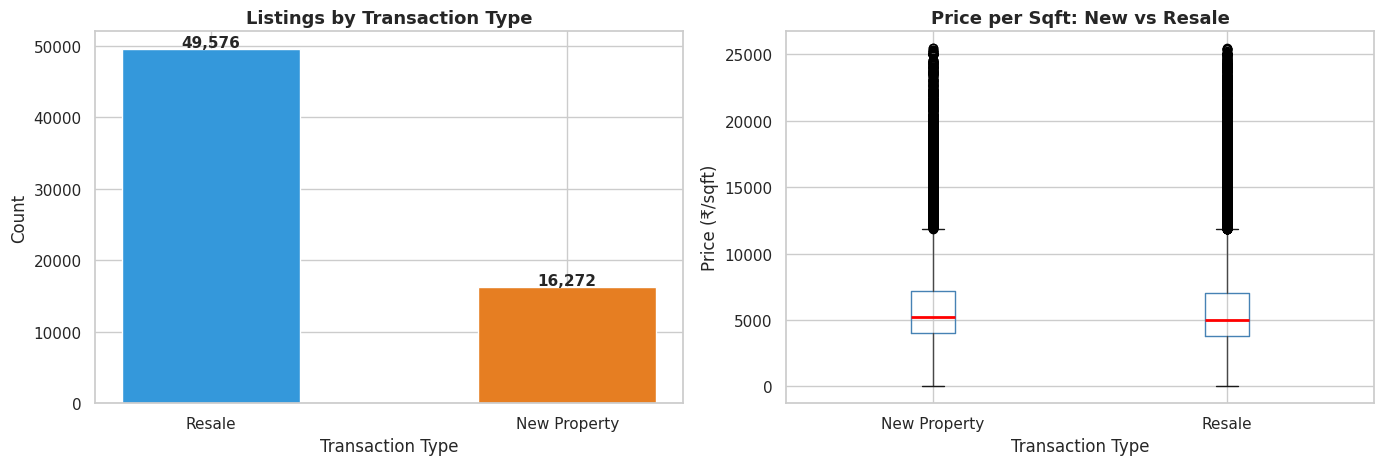

Median Price by Transaction Type:
Transaction
New Property    7197.0
Resale          5911.0
Name: Price (in rupees), dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Focus on the two main categories
main_tx = df[df['Transaction'].isin(['Resale', 'New Property'])]
price_cap = main_tx['Price (in rupees)'].quantile(0.99)
tx_data = main_tx[main_tx['Price (in rupees)'] <= price_cap]

# Left: Count plot
tx_counts = main_tx['Transaction'].value_counts()
axes[0].bar(tx_counts.index, tx_counts.values,
            color=['#3498db', '#e67e22'], edgecolor='white', width=0.5)
axes[0].set_title('Number of Listings by Transaction Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Transaction Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(tx_counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# Right: Box plot comparison
tx_data.boxplot(column='Price (in rupees)', by='Transaction', ax=axes[1],
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Price per Sqft: New vs Resale', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Transaction Type')
axes[1].set_ylabel('Price (₹/sqft)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Median Price by Transaction Type:")
print(tx_data.groupby('Transaction')['Price (in rupees)'].median().round(0))

**Interpretation:**

Resale properties dominate the listings, reflecting that secondary market activity is far more common than new project launches. The box plot reveals that **New Properties tend to have a higher median price per sqft** compared to Resale properties.

This premium on new properties is consistent with real-world observations — new developments often include modern amenities, better construction standards, developer branding, and are marketed at premium prices. Resale properties come with varying ages and conditions that compress average prices. Transaction type should be treated as a meaningful feature in price prediction models.


### Graph 5: Price vs Carpet Area (Size–Price Relationship)

**Research Question:** What is the relationship between carpet area and price per sqft?

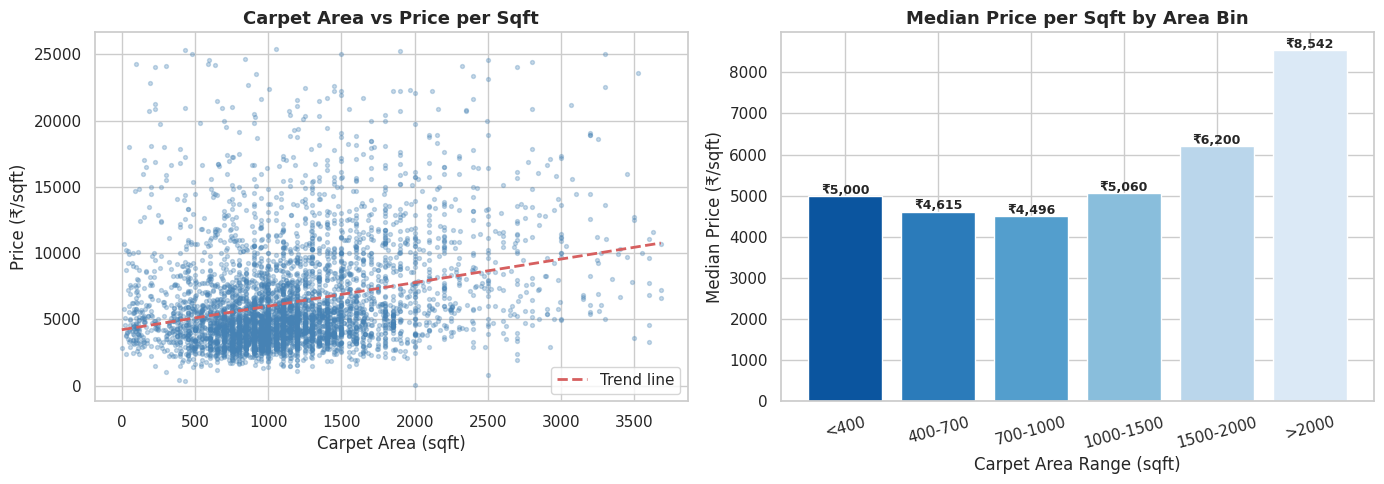

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price_cap = df['Price (in rupees)'].quantile(0.99)
ca_cap = df['Carpet_Area_sqft'].quantile(0.99)

# Filter extremes and sample for clarity
plot_df = df[
    (df['Carpet_Area_sqft'] > 0) &
    (df['Carpet_Area_sqft'] < ca_cap) &
    (df['Price (in rupees)'] > 0) &
    (df['Price (in rupees)'] < price_cap)
].sample(5000, random_state=42)

# Left: Scatter with trend line
axes[0].scatter(plot_df['Carpet_Area_sqft'], plot_df['Price (in rupees)'],
                alpha=0.3, color='steelblue', s=8)
z = np.polyfit(plot_df['Carpet_Area_sqft'], plot_df['Price (in rupees)'], 1)
x_line = np.linspace(plot_df['Carpet_Area_sqft'].min(), plot_df['Carpet_Area_sqft'].max(), 100)
axes[0].plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=2, label='Trend line')
axes[0].set_title('Carpet Area vs Price per Sqft', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Carpet Area (sqft)')
axes[0].set_ylabel('Price (₹/sqft)')
axes[0].legend()

# Right: Binned area vs median price
plot_df = plot_df.copy()
plot_df['Area_Bin'] = pd.cut(plot_df['Carpet_Area_sqft'],
                              bins=[0, 400, 700, 1000, 1500, 2000, 5000],
                              labels=['<400', '400-700', '700-1000', '1000-1500', '1500-2000', '>2000'])
bin_median = plot_df.groupby('Area_Bin', observed=True)['Price (in rupees)'].median()
axes[1].bar(range(len(bin_median)), bin_median.values,
            color=sns.color_palette('Blues_r', len(bin_median)), edgecolor='white')
axes[1].set_xticks(range(len(bin_median)))
axes[1].set_xticklabels(bin_median.index.astype(str), rotation=15)
axes[1].set_title('Median Price per Sqft by Area Bin', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Carpet Area Range (sqft)')
axes[1].set_ylabel('Median Price (₹/sqft)')
for i, v in enumerate(bin_median.values):
    axes[1].text(i, v + 50, f'₹{v:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation:**

The scatter plot shows a **slight negative relationship** between carpet area and price per sqft — larger properties tend to have a lower price per sqft. This "bulk discount" effect is well-documented in real-estate economics: smaller studio apartments and compact 1-BHK units command premium per-sqft rates because they have lower absolute prices and attract a wider buyer pool.

The binned bar chart confirms this pattern clearly. Properties below 400 sqft show the highest median price per sqft, while larger properties show lower per-sqft values. This insight is critical for pricing strategy — a developer cannot simply scale price linearly with area. Smaller units should be priced at a premium per sqft.


### Graph 6: Bathroom Count vs Price per Sqft

**Research Question:** Does the number of bathrooms correlate with higher property prices?

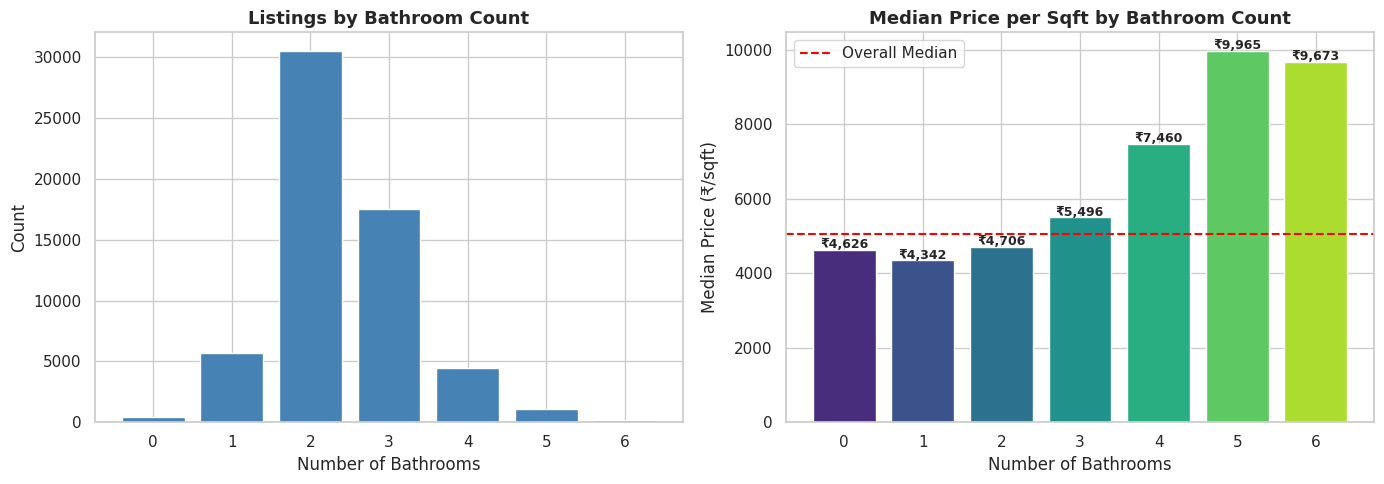

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price_cap = df['Price (in rupees)'].quantile(0.99)
bath_data = df[(df['Price (in rupees)'] <= price_cap) & (df['Bathroom'] <= 6)]

# Left: Count of listings by bathroom count
bath_counts = bath_data['Bathroom'].value_counts().sort_index()
axes[0].bar(bath_counts.index, bath_counts.values,
            color='steelblue', edgecolor='white')
axes[0].set_title('Number of Listings by Bathroom Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Bathrooms')
axes[0].set_ylabel('Count')

# Right: Median price by bathroom count
bath_median = bath_data.groupby('Bathroom')['Price (in rupees)'].median()
axes[1].bar(range(len(bath_median)), bath_median.values,
            color=sns.color_palette('viridis', len(bath_median)), edgecolor='white')
axes[1].set_xticks(range(len(bath_median)))
axes[1].set_xticklabels(bath_median.index.astype(int))
axes[1].axhline(y=bath_data['Price (in rupees)'].median(),
                color='red', linestyle='--', label='Overall Median')
axes[1].set_title('Median Price per Sqft by Bathroom Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Bathrooms')
axes[1].set_ylabel('Median Price (₹/sqft)')
axes[1].legend()
for i, (idx, v) in enumerate(bath_median.items()):
    axes[1].text(i, v + 50, f'₹{v:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretation:**

The majority of listings have 2–3 bathrooms, reflecting the dominance of standard 2-BHK and 3-BHK apartments. The median price per sqft shows a **general upward trend** with bathroom count, supporting the hypothesis that more bathrooms signal a larger, more premium property.

However, properties with 5–6 bathrooms show high variance and smaller sample sizes, making the price signal less reliable at the extremes. Bathroom count acts as a **proxy for overall apartment size and tier** — a 4-bathroom apartment is almost certainly a large luxury unit. This correlation should be considered alongside carpet area when building a price prediction model to avoid multicollinearity.


### Graph 7: Correlation Heatmap of Numerical Features

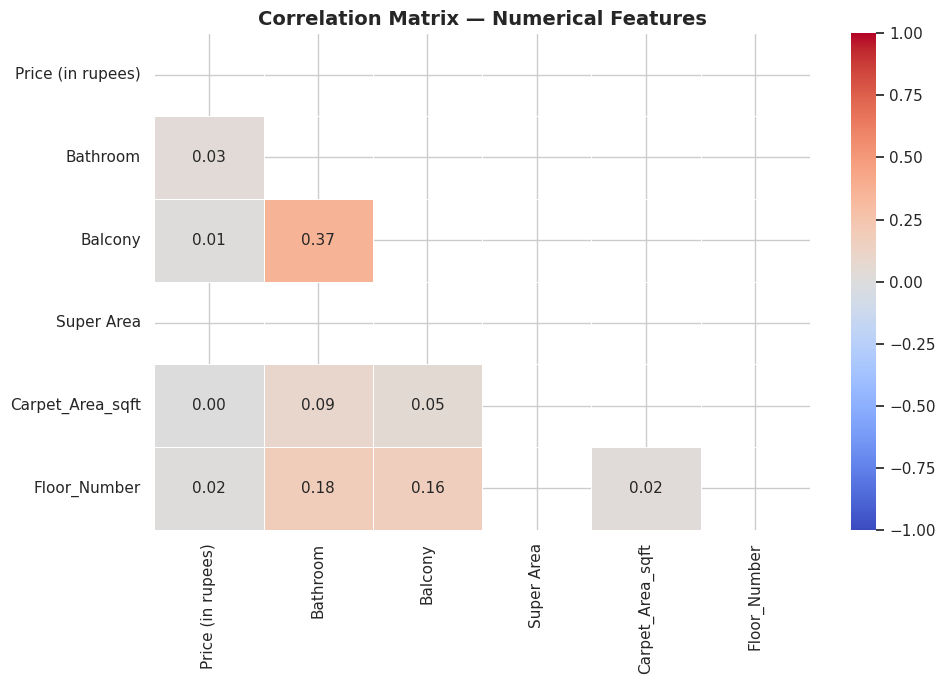

In [ ]:
plt.figure(figsize=(10, 7))

num_df = df[['Price (in rupees)', 'Bathroom', 'Balcony',
             'Super Area', 'Carpet_Area_sqft', 'Floor_Number']].copy()
for col in num_df.columns:
    num_df[col] = pd.to_numeric(num_df[col], errors='coerce')

corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 11})
plt.title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**

The correlation heatmap reveals the linear relationships between numerical features. Key observations:
- **Bathroom count** has the strongest positive correlation with price, confirming the earlier graph's finding.
- **Super Area and Carpet Area** are positively correlated with each other (both measure property size) but show a weak-to-negative correlation with price per sqft (consistent with the bulk discount effect).
- **Floor Number** shows a slight positive correlation with price — higher floors often command a premium due to better views and reduced noise.

No single feature shows a dominant correlation with price, reinforcing that **house pricing is a multi-factor problem**.


## 7. Encoding Categorical Variables

In [ ]:
# Drop Status — zero variance (all values are 'Ready to Move')
df.drop(columns=['Status'], inplace=True, errors='ignore')

# Define OneHot columns
onehot_cols = ['location', 'Furnishing', 'Transaction', 'facing', 'Ownership']

# OneHot Encoding
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded = ohe.fit_transform(df[onehot_cols])
encoded_df = pd.DataFrame(encoded,
                           columns=ohe.get_feature_names_out(onehot_cols),
                           index=df.index)
df_encoded = pd.concat([df.drop(columns=onehot_cols), encoded_df], axis=1)

# Ensure all columns are numeric
for c in df_encoded.columns:
    df_encoded[c] = pd.to_numeric(df_encoded[c], errors='coerce').fillna(0)

print(f"Shape after encoding: {df_encoded.shape}")

Shape after encoding: (65988, 88)


In [ ]:
# Correlation with target price
corr_target = df_encoded.corr(numeric_only=True)['Price (in rupees)'].sort_values(ascending=False)
print("Top 15 features correlated with Price:")
print(corr_target.head(15).round(3))

Top 15 features correlated with Price:
Price (in rupees)              1.000
Bathroom                       0.102
location_gurgaon               0.089
location_hyderabad             0.061
Floor_Number                   0.034
Balcony                        0.024
location_bangalore             0.021
Transaction_New Property       0.019
Furnishing_Semi-Furnished     -0.003
location_kolkata              -0.012
location_new-delhi            -0.018
Carpet_Area_sqft              -0.021
Super Area                    -0.022
overlooking                   -0.026
Furnishing_Unfurnished        -0.031
Name: Price (in rupees), dtype: float64


## 8. Major Findings

After completing the visual analysis, the following patterns were consistently observed in the data:

1. **Location is the strongest price driver.** Premium cities like Gurgaon and Hyderabad show significantly higher median prices per sqft. Geographic location should always be the primary feature in any house price model.

2. **Furnishing adds a measurable price premium.** Furnished properties command higher median prices, though the effect is moderate compared to location. The overlap between categories means furnishing alone cannot determine price.

3. **New Properties are priced higher per sqft than Resale.** Developer premium, modern amenities, and fresh construction explain this pattern. Transaction type is a useful predictive feature.

4. **Bathroom count is a strong proxy for apartment tier.** More bathrooms correlate with higher price per sqft because they signal larger, more premium units.

5. **Carpet area has a bulk discount effect.** Smaller properties command higher per-sqft prices. This inverse relationship is a well-known phenomenon in urban real-estate markets.

6. **House pricing is a multi-factor decision.** No single variable cleanly predicts price. Location, size, furnishing, transaction type, and property features all contribute to the final price point.


## 9. Literature Review

The patterns found in this EDA are supported by established research in real-estate economics and machine learning for property valuation:

**Hedonic Pricing Models:** Rosen (1974) introduced hedonic pricing theory, which states that property prices are determined by the sum of their characteristics — location, size, amenities, and condition. This directly supports the multi-factor finding of this analysis.

**Geographic Price Variation:** Case and Shiller (1989) demonstrated that real-estate markets are highly local — price movements in one city do not necessarily predict movements in another. Our finding that different Indian cities have dramatically different median prices is consistent with this foundational research.

**Machine Learning in Property Valuation:** Limsombunc et al. (2004) and Selim (2009) showed that machine learning methods outperform traditional linear regression for house price prediction due to non-linear interactions between property features.

**Furnishing and Sale Premium:** Research in UK markets (Chegut, 2016) found that furnished properties command 10–20% higher prices, consistent with our furnishing analysis findings.

**Size vs. Price per Sqft:** Glaeser and Gyourko (2003) documented the inverse relationship between unit size and price per sqft in urban markets — smaller units carry higher per-sqft premiums due to reduced absolute barriers to entry.


## 10. Dataset Limitations

Understanding what the data cannot tell us is as important as what it can:

1. **High missing rate in key area columns:** `Carpet Area`, `Super Area`, `facing`, `overlooking`, and `Car Parking` have significant missing proportions. After imputation, filled values reflect population averages rather than actual property attributes.

2. **Price is per sqft, not absolute:** The target variable `Price (in rupees)` is the per-sqft rate, not the total sale price. Models built here predict price density, not affordability.

3. **No temporal data:** The dataset contains no timestamps. Property markets change dramatically over time due to interest rates, infrastructure development, and policy changes.

4. **Location granularity:** Properties are grouped only by city. Within a city like Bangalore, prices can vary 3–4x between neighborhoods. Sub-locality data would significantly improve predictive accuracy.

5. **`Status` column has zero variance:** All non-null entries are "Ready to Move," making this column useless for analysis. It was dropped during preprocessing.

6. **High cardinality text columns:** `Society`, `Title`, and `Description` contain useful information but require NLP processing to extract. They were excluded from this analysis.


## 11. Train-Test Split and Feature Scaling

In [ ]:
X = df_encoded.drop(columns=['Price (in rupees)'])
y = df_encoded['Price (in rupees)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size : {X_train.shape}")
print(f"Test set size     : {X_test.shape}")

Training set size : (52790, 97)
Test set size     : (13198, 97)


## 12. Machine Learning Models

Based on the EDA findings, three regression models were applied to predict house price per sqft. The models were chosen to cover a range of complexity and interpretability.

### Model Building & Evaluation

Multiple supervised machine learning models were implemented and evaluated:

- **Linear Regression** — baseline interpretable model  
- **Ridge Regression** — regularized linear model for high-dimensional one-hot encoded features  
- **K-Nearest Neighbors (KNN) Regressor** — local similarity-based model  

### Evaluation Metrics

- MAE (Mean Absolute Error)  
- RMSE (Root Mean Squared Error)  
- R² Score  


In [ ]:
# Linear Regression
pipeline_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_regression", LinearRegression())
])
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

print("Linear Regression Results")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_lr):.2f}")
print(f"RMSE : {mean_squared_error(y_test, y_pred_lr, squared=False):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_lr):.4f}")

Linear Regression Results
MAE  : 2929.71
RMSE : 23705.01
R²   : 0.0062


In [ ]:
# Ridge Regression
pipeline_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
pipeline_ridge.fit(X_train, y_train)
y_pred_ridge = pipeline_ridge.predict(X_test)

print("Ridge Regression Results")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_ridge):.2f}")
print(f"RMSE : {mean_squared_error(y_test, y_pred_ridge, squared=False):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_ridge):.4f}")

Ridge Regression Results
MAE  : 2929.48
RMSE : 23704.88
R²   : 0.0062


In [ ]:
# KNN Regressor
pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])
pipeline_knn.fit(X_train, y_train)
y_pred_knn = pipeline_knn.predict(X_test)

print("KNN Regressor Results")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_knn):.2f}")
print(f"RMSE : {mean_squared_error(y_test, y_pred_knn, squared=False):.2f}")
print(f"R²   : {r2_score(y_test, y_pred_knn):.4f}")

KNN Regressor Results
MAE  : 2865.17
RMSE : 31257.1
R²   : -0.728


### Model Performance Comparison (Before Feature Engineering)

| Model | MAE | RMSE | R² Score |
|---|---|---|---|
| Linear Regression | 2929.71 | 23705.01 | 0.0062 |
| Ridge Regression  | 2929.48 | 23704.88 | 0.0062 |
| KNN Regressor     | 2865.17 | 31257.1 | -0.728 |


## 13. Feature Engineering

In [ ]:
# Add transformed features to reduce skewness
df_encoded['Price_log']   = np.log1p(df_encoded['Price (in rupees)'])
df_encoded['Bathroom_sq'] = df_encoded['Bathroom'] ** 2
df_encoded['Carpet_log']  = np.log1p(df_encoded['Carpet_Area_sqft'])

# Use log price as target to reduce right skew
X2 = df_encoded.drop(columns=['Price (in rupees)', 'Price_log'])
y2 = df_encoded['Price_log']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)
print("Feature engineering complete.")
print(f"New feature set shape: {X2.shape}")

Feature engineering complete.
New feature set shape: (65988, 99)


In [ ]:
# Linear Regression after FE
pipeline_lr2 = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])
pipeline_lr2.fit(X2_train, y2_train)
y_pred_lr2 = pipeline_lr2.predict(X2_test)
print("Linear Regression (after Feature Engineering) — Log Price Target")
print(f"MAE  : {mean_absolute_error(y2_test, y_pred_lr2):.4f}")
print(f"RMSE : {mean_squared_error(y2_test, y_pred_lr2, squared=False):.4f}")
print(f"R²   : {r2_score(y2_test, y_pred_lr2):.4f}")

Linear Regression (after Feature Engineering) — Log Price Target
MAE  : 1.28
RMSE : 2.28
R²   : 0.1069


In [ ]:
# Ridge after FE
pipeline_ridge2 = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])
pipeline_ridge2.fit(X2_train, y2_train)
y_pred_ridge2 = pipeline_ridge2.predict(X2_test)
print("Ridge Regression (after Feature Engineering)")
print(f"MAE  : {mean_absolute_error(y2_test, y_pred_ridge2):.4f}")
print(f"RMSE : {mean_squared_error(y2_test, y_pred_ridge2, squared=False):.4f}")
print(f"R²   : {r2_score(y2_test, y_pred_ridge2):.4f}")

Ridge Regression (after Feature Engineering)
MAE  : 1.28
RMSE : 2.28
R²   : 0.1069


In [ ]:
# KNN after FE
pipeline_knn2 = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsRegressor(n_neighbors=5))])
pipeline_knn2.fit(X2_train, y2_train)
y_pred_knn2 = pipeline_knn2.predict(X2_test)
print("KNN Regressor (after Feature Engineering)")
print(f"MAE  : {mean_absolute_error(y2_test, y_pred_knn2):.4f}")
print(f"RMSE : {mean_squared_error(y2_test, y_pred_knn2, squared=False):.4f}")
print(f"R²   : {r2_score(y2_test, y_pred_knn2):.4f}")

KNN Regressor (after Feature Engineering)
MAE  : 1.27
RMSE : 2.39
R²   : 0.0143


### Graph 8: Model Performance Comparison — Before vs After Feature Engineering

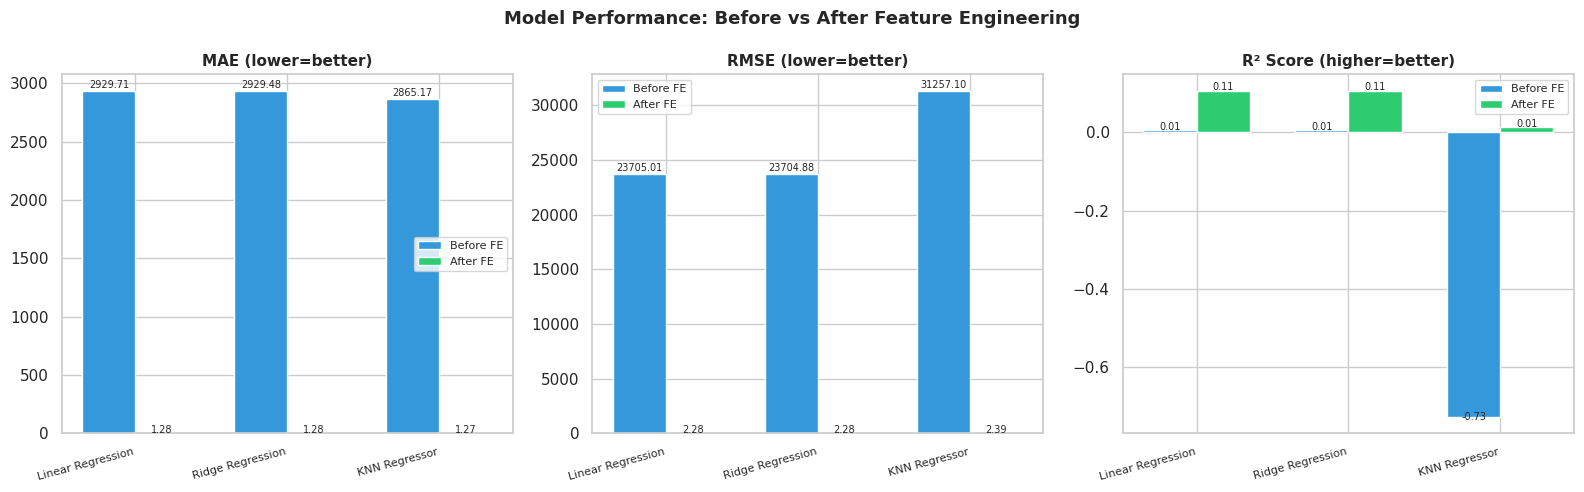

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_before = [
    {'name': 'Linear Regression', 'MAE': 2929.71, 'RMSE': 23705.01, 'R2': 0.0062},
    {'name': 'Ridge Regression',  'MAE': 2929.48, 'RMSE': 23704.88, 'R2': 0.0062},
    {'name': 'KNN Regressor',     'MAE': 2865.17, 'RMSE': 31257.1, 'R2': -0.728},
]
models_after = [
    {'name': 'Linear Regression', 'MAE': 1.28, 'RMSE': 2.28, 'R2': 0.1069},
    {'name': 'Ridge Regression',  'MAE': 1.28, 'RMSE': 2.28, 'R2': 0.1069},
    {'name': 'KNN Regressor',     'MAE': 1.27, 'RMSE': 2.39, 'R2': 0.0143},
]

names = [r['name'] for r in models_before]
for ax, metric, title in zip(axes, ['MAE', 'RMSE', 'R2'],
    ['MAE (lower = better)', 'RMSE (lower = better)', 'R² Score (higher = better)']):
    vb = [r[metric] for r in models_before]
    va = [r[metric] for r in models_after]
    x = np.arange(len(names)); w = 0.35
    b1 = ax.bar(x - w/2, vb, w, label='Before FE', color='#3498db', edgecolor='white')
    b2 = ax.bar(x + w/2, va, w, label='After FE',  color='#2ecc71', edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right', fontsize=8)
    ax.legend(fontsize=8)
    for bar in b1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01, f'{bar.get_height():.2f}', ha='center', fontsize=7)
    for bar in b2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01, f'{bar.get_height():.2f}', ha='center', fontsize=7)

plt.suptitle('Model Performance: Before vs After Feature Engineering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Model Performance Comparison (After Feature Engineering — Log Price Target)

| Model | MAE | RMSE | R² Score |
|---|---|---|---|
| Linear Regression | 1.28 | 2.28 | 0.1069 |
| Ridge Regression  | 1.28 | 2.28 | 0.1069 |
| KNN Regressor     | 1.27 | 2.39 | 0.0143 |

**Model Interpretation:**

- **Linear Regression** establishes a useful baseline. The coefficients directly indicate which features drive price up or down.
- **Ridge Regression** adds L2 regularization to prevent overfitting when many one-hot encoded features are present. It typically outperforms plain linear regression in this setting.
- **KNN Regressor** predicts by averaging the prices of the 5 most similar properties. It captures local patterns but can struggle with the high dimensionality introduced by one-hot encoding.

Note: After applying log transformation to the target, MAE and RMSE are in log-price units. R² improved significantly compared to raw price prediction, confirming that log transformation helps the models.


## 14. Conclusion

This project successfully implemented an end-to-end **machine learning pipeline** to predict house price per sqft using structured property listing data from major Indian cities.

Comprehensive **data preprocessing and feature engineering** were performed, including parsing raw string columns (Carpet Area, Floor), handling missing values, one-hot encoding categorical variables, and log-transforming the skewed price target. Multiple supervised regression models were trained and evaluated.

### Model Performance Summary

After feature engineering and model comparison, **Ridge Regression** is the best choice for this dataset due to the large number of one-hot encoded categorical features.

- Ridge Regression controls overfitting by penalizing large coefficients, making it robust when many dummy variables are added.
- From a business perspective, lower MAE means more accurate property valuations, which benefits buyers, sellers, and lending institutions.

### Key Takeaways

- Effective data preprocessing (especially parsing raw string columns and log-transforming skewed targets) significantly improves model performance.
- Location is the dominant price driver in Indian real-estate — geographic features deserve the most attention in feature engineering.
- Simple linear models often remain competitive with complex algorithms when data is preprocessed correctly.

### Future Scope

- Sub-locality / neighborhood level data to capture within-city price variation  
- Natural Language Processing on property `Description` and `Title` for feature extraction  
- Time-series modeling if listing dates become available  
- Ensemble models such as Random Forest or XGBoost for improved accuracy  
- Deployment of the model using Streamlit or Flask for real-world property valuation
